# 1. 주택 임대료 예측 데이터셋
House Rent Prediction Dataset은 주택 임대료를 예측하기 위한 목적으로 사용되는 데이터셋이다. 이 데이터셋은 주로 머신러닝 및 데이터 분석 프로젝트에서 사용되며, 주택의 다양한 특성과 위치 정보를 기반으로 임대료를 예측하는 모델을 학습하는 데 활용된다.

# **2. 데이터셋 컬럼**
```
BHK: 주택에 포함된 침실, 거실, 주방의 총 개수를 의미합니다.
Rent: 주택(아파트/플랫)의 월 임대료를 나타냅니다.
Size: 주택(아파트/플랫)의 면적을 평방피트(Square Feet)로 나타냅니다.
Floor: 주택이 위치한 층수와 건물의 총 층수를 나타냅니다. (예: 2층 중 1층, 5층 중 3층 등)
Area Type: 주택의 면적이 어떤 방식으로 계산되었는지를 나타냅니다. (예: 전체 면적, 실사용 면적, 건축 면적 등)
Area Locality: 주택(아파트/플랫)이 위치한 구체적인 지역이나 동네 정보를 나타냅니다.
City: 주택(아파트/플랫)이 위치한 도시를 나타냅니다.
Furnishing Status: 주택이 가구가 완비되었는지(Furnished), 부분적으로 갖추어졌는지(Semi-Furnished), 아니면 비어 있는지(Unfurnished)를 나타냅니다.
Tenant Preferred: 집주인 또는 중개인이 선호하는 임차인 유형을 나타냅니다. (예: 가족, 싱글, 직장인 등)
Bathroom: 주택에 있는 욕실의 개수를 나타냅니다.
Point of Contact: 주택(아파트/플랫)에 대한 추가 정보를 얻기 위해 연락해야 할 담당자나 중개인의 정보를 나타냅니다.
```

# 3. 데이터셋 전처리

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
rent_df = pd.read_csv('./source/House_Rent_Dataset.csv')
rent_df

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner
...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent


In [3]:
rent_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 445.1 KB


In [4]:
rent_df.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [5]:
round(rent_df.describe(), 2) # 소수점 둘째자리까지만 표현

,BHK,Rent,Size,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,2.08,34993.45,967.49,1.97
std,0.83,78106.41,634.20,0.88
min,1.00,1200.00,10.00,1.00
25%,2.00,10000.00,550.00,1.00
50%,2.00,16000.00,850.00,2.00
75%,3.00,33000.00,1200.00,2.00
max,6.00,3500000.00,8000.00,10.00


In [6]:
rent_df['BHK']

0       2
1       2
2       2
3       2
4       2
       ..
4741    2
4742    3
4743    3
4744    3
4745    2
Name: BHK, Length: 4746, dtype: int64

In [7]:
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'

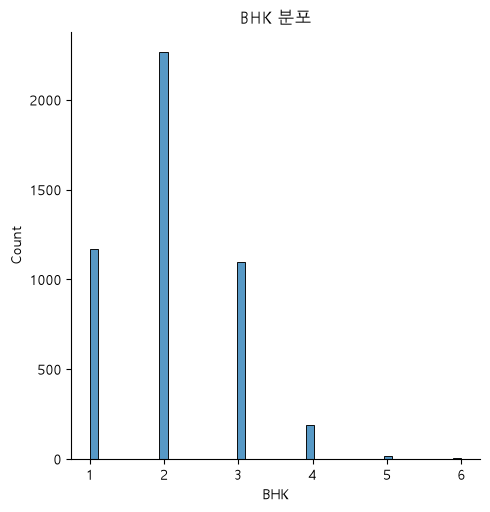

In [8]:
sns.displot(rent_df['BHK'])
plt.title('BHK 분포')
plt.show()

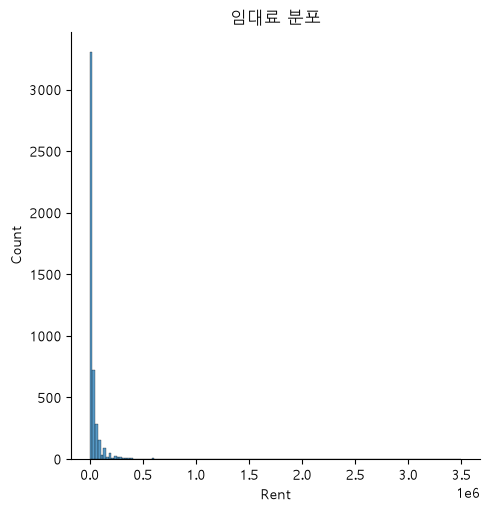

In [9]:
sns.displot(rent_df['Rent'])
plt.title('임대료 분포')
plt.show()

In [10]:
rent_df['Rent'].sort_values()

4076       1200
285        1500
471        1800
2475       2000
146        2200
         ...   
1459     700000
1329     850000
827     1000000
1001    1200000
1837    3500000
Name: Rent, Length: 4746, dtype: int64

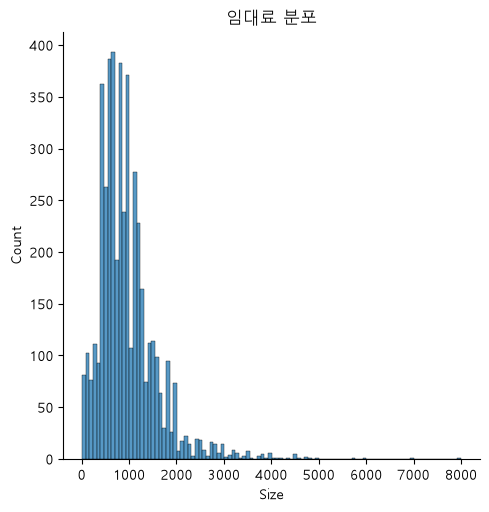

In [11]:
sns.displot(rent_df['Size'])
plt.title('임대료 분포')
plt.show()

In [12]:
rent_df['Size'].sort_values()

4653      10
116       20
2973      25
3922      25
2460      25
        ... 
1001    5000
2048    5700
3622    6000
4457    7000
4185    8000
Name: Size, Length: 4746, dtype: int64

### boxplot
Boxplot은 데이터의 중앙값, 사분위수, 이상치 등을 시각적으로 표현하는 통계 그래프이다. 주로 데이터 분포와 이상치를 빠르게 파악하기 위해 사용한다.

1. 중앙값 (Median, Q2): 데이터를 크기 순으로 정렬했을 때 중간에 위치한 값
2. Q1 (제1사분위수, 25%): 하위 25%에 해당하는 값
3. Q3 (제3사분위수, 75%): 상위 25%에 해당하는 값
4. IQR (Interquartile Range, 사분위 범위): Q3 - Q1, IQR은 데이터의 중간 50% 범위를 의미합니다.
5. Minimum: Q1 − 1.5 × IQR 이하에 속하지 않는 가장 작은 값
6. Maximum: Q3 + 1.5 × IQR 이하에 속하지 않는 가장 큰 값
7. 이상치: 일반적인 데이터 분포를 벗어난 값(Lower Bound=Q1−1.5×IQR, Upper Bound=Q3+1.5×IQR)
( IQR 기준으로 이상치를 정의하기 때문에 모든 상황에 완벽하지 않을 수 있다)

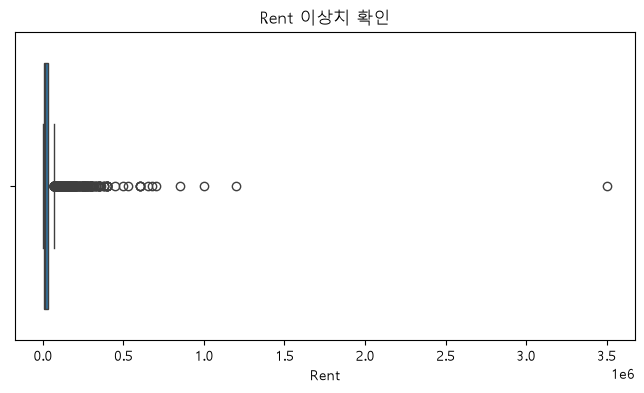

In [13]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=rent_df['Rent'])
plt.title('Rent 이상치 확인')
plt.show()
# boxplot을 벗어난 값을 이상치라고 판단하기 어려울 수도 있음

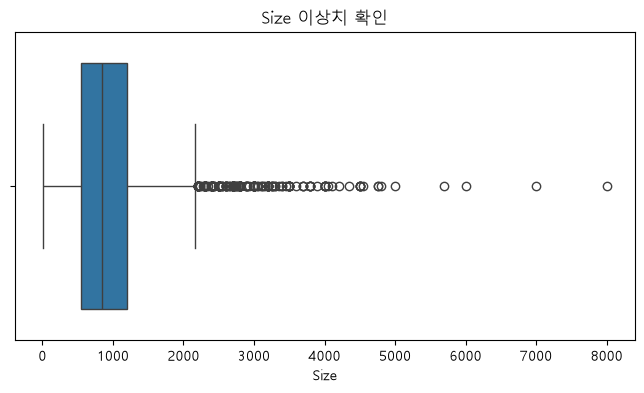

In [14]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=rent_df['Size'])
plt.title('Size 이상치 확인')
plt.show()

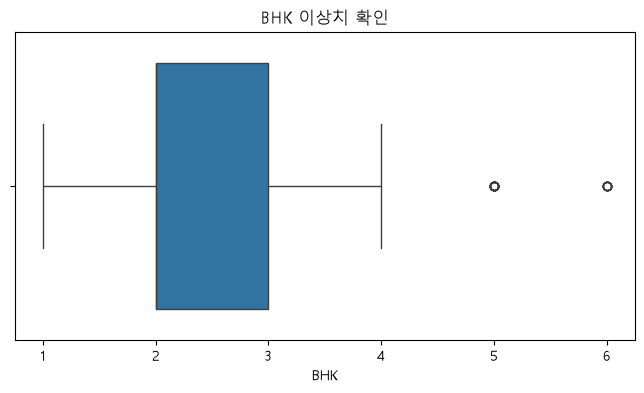

In [15]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=rent_df['BHK'])
plt.title('BHK 이상치 확인')
plt.show()

In [16]:
rent_df.isna().sum() # 결측치 확인

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [17]:
rent_df.isna().mean()

Posted On            0.0
BHK                  0.0
Rent                 0.0
Size                 0.0
Floor                0.0
Area Type            0.0
Area Locality        0.0
City                 0.0
Furnishing Status    0.0
Tenant Preferred     0.0
Bathroom             0.0
Point of Contact     0.0
dtype: float64

In [18]:
rent_df['Area Type'].unique() # 데이터 값의 종류 확인

<StringArray>
['Super Area', 'Carpet Area', 'Built Area']
Length: 3, dtype: str

In [19]:
rent_df['Area Type'].nunique() # 데이터 값의 종류 개수 확인

3

In [20]:
for i in ['Posted On', 'Floor', 'Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact']:
    print(i, rent_df[i].nunique())

Posted On 81
Floor 480
Area Type 3
Area Locality 2235
City 6
Furnishing Status 3
Tenant Preferred 3
Point of Contact 3


In [21]:
rent_df.select_dtypes(include='str').columns # str 타입의 컬럼만 추출;str 타입은 전처리 과정에서 불편함

Index(['Posted On', 'Floor', 'Area Type', 'Area Locality', 'City',
       'Furnishing Status', 'Tenant Preferred', 'Point of Contact'],
      dtype='str')

In [22]:
obj_cols =  rent_df.select_dtypes(include='str').columns
for col in obj_cols:
    print(col, rent_df[col].nunique())

Posted On 81
Floor 480
Area Type 3
Area Locality 2235
City 6
Furnishing Status 3
Tenant Preferred 3
Point of Contact 3


In [23]:
# 문자열 컬럼이라고 해서 무조건 삭제하지 않고 숫자로 의미있게 변환할 수 있는 칼럼은 가공함
# Posted On
rent_df['Posted On'] = pd.to_datetime(rent_df['Posted On'])
rent_df['Posted_Year'] = rent_df['Posted On'].dt.year
rent_df['Posted_Month'] = rent_df['Posted On'].dt.month
rent_df['Posted_DayOfWeek'] = rent_df['Posted On'].dt.dayofweek

In [24]:
# Floor: 'Ground out of 2', '3 out of 5' 등의 문자열
# extract: 문자열에서 특정 패턴을 찾아서 뽑아내는 함수
# 현재층 out of 전체층
# r': Raw string(원시 문자열)
# \d+ : 숫자 1개 이상
# \s+ : 공백 1개 이상
# (?P<name>\d+)에서 숫자를 찾고 그 결과 컬럼 이름을 name으로 붙임
# 3 out of 10 -> Current_Floor 3, Total_Floors 10
# Ground out of 2 -> Current_Floor Ground, Total_Floors 2
floor_pattern = (
    r'(?P<Current_Floor>Upper Basement|Lower Basement|Ground|Upper|Lower|Basement|\d+)'
    r'\s+out of\s+'
    r'(?P<Total_Floors>\d+)'
)

floor_split = rent_df['Floor'].astype(str).str.extract(floor_pattern)

floor_map = {
    'Ground': 0,
    'Lower': 0,
    'Basement': -1,
    'Upper': np.nan,
    'Upper Basement': -1,
    'Lower Basement': -1
}

# 정규식으로 분리되지 않은 원본값 확인
unmatched_floor_values = rent_df.loc[floor_split['Current_Floor'].isna(), 'Floor'].value_counts()
unmatched_floor_values

Floor
1         2
3         1
Ground    1
Name: count, dtype: int64

In [25]:
# rent_df['Current_Floor'] = floor_split['Current_Floor'].replace(floor_map).astype(float)
# rent_df['Total_Floors'] = floor_split['Total_Floors'].astype(float)
# replace 후에 바로 astype(int)로 변환하면 NaN이 존재할 경우 에러 발생
# pd.to_numeric(errors='coerce')를 사용하면  안전하게 숫자 변환
rent_df['Current_Floor'] = floor_split['Current_Floor'].replace(floor_map)
rent_df['Current_Floor'] = pd.to_numeric(rent_df['Current_Floor'], errors='coerce')
rent_df['Total_Floors'] = pd.to_numeric(floor_split['Total_Floors'], errors='coerce')

In [26]:
# Upper는 정확한 층수를 알 수 없으므로 Total_Floors 값으로 처리
# 예시: Upper out of 4 -> 4층으로 간주
Upper_mask = rent_df['Current_Floor'].isna() & floor_split['Current_Floor'].eq('Upper')
rent_df.loc[Upper_mask, 'Current_Floor'] = rent_df.loc[Upper_mask, 'Total_Floors']

# 추가 파생변수: 잔체 층수 대비 현재 층의 위치
rent_df['Floor_Ratio'] = rent_df['Current_Floor'] / rent_df['Total_Floors']
rent_df['Floor_Ratio'] = rent_df['Floor_Ratio'].replace([np.inf, -np.inf], np.nan)

rent_df[['Floor', 'Current_Floor', 'Total_Floors', 'Floor_Ratio']].head()

,Floor,Current_Floor,Total_Floors,Floor_Ratio
0,Ground out of 2,0.0,2.0,0.000000
1,1 out of 3,1.0,3.0,0.333333
2,1 out of 3,1.0,3.0,0.333333
3,1 out of 2,1.0,2.0,0.500000
4,1 out of 2,1.0,2.0,0.500000


In [27]:
rent_df.drop(['Floor', 'Posted On'], axis=1, inplace=True)
rent_df

,BHK,Rent,Size,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Posted_Year,Posted_Month,Posted_DayOfWeek,Current_Floor,Total_Floors,Floor_Ratio
0,2,10000,1100,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,2022,5,2,0.0,2.0,0.000000
1,2,20000,800,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,2022,5,4,1.0,3.0,0.333333
2,2,17000,1000,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,2022,5,0,1.0,3.0,0.333333
3,2,10000,800,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,2022,7,0,1.0,2.0,0.500000
4,2,7500,850,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner,2022,5,0,1.0,2.0,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2,15000,1000,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner,2022,5,2,3.0,5.0,0.600000
4742,3,29000,2000,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner,2022,5,6,1.0,4.0,0.250000
4743,3,35000,1750,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent,2022,7,6,3.0,5.0,0.600000
4744,3,45000,1500,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent,2022,7,2,23.0,34.0,0.676471


In [28]:
# Area Locality는 지역 정보이므로 삭제하지 않고 범주형 변수로 변환
# 전체 데이터에서 빈도 인코딩을 먼저하면 학습 데이터와 테스트 데이터의 분포가 달라서 학습 데이터에 없는 지역이 테스트 데이터에 존재할 경우와 같은 데이터 누수 문제가 발생할 수 있음
# Pipeline 내부의 OneHotEncoder를 사용하여 학습 데이터에서만 빈도 인코딩을 수행하도록 처리


In [29]:
# 전처리 + 모델링을 위해 X, y를 먼저 분리
X = rent_df.drop('Rent', axis=1)
y = rent_df['Rent']

In [30]:
# 숫자 컬럼과 문자 컬럼을 분리
numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(include=['str', 'category', 'object', 'bool']).columns.tolist()

print('숫자형 컬럼:', numeric_features)
print('범주형 컬럼:', categorical_features)
print('결측치 개수:', X.isna().sum())

숫자형 컬럼: ['BHK', 'Size', 'Bathroom', 'Posted_Year', 'Posted_Month', 'Posted_DayOfWeek', 'Current_Floor', 'Total_Floors', 'Floor_Ratio']
범주형 컬럼: ['Area Type', 'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact']
결측치 개수: BHK                  0
Size                 0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
Posted_Year          0
Posted_Month         0
Posted_DayOfWeek     0
Current_Floor        4
Total_Floors         4
Floor_Ratio          4
dtype: int64


In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2026)

### Pipeline
- 데이터 전처리 + 모델 학습을 자동으로 연결한 작업 흐름
```py
pipe = Pipline([
    ('이름1', '작업1'),
    ('이름2', '작업2'),
    ('이름3', '작업3'),
])
```


### 머신러닝 작업 순서
1. 결측치 처리
2. 문자열 숫자화(라벨 인코딩)
3. 스케일링
4. 모델 학습

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

In [34]:
# 테스트 데이터에 학습 떄 못 본 지역/도시/옵션이 나와도 에러가 나지 않도록 함
onehot = OneHotEncoder(handle_unknown='ignore')

# 숫자 결측치는 중앙값으로 대체., 평균보다 이상치 영향이 작아 자주 사용됨
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# 문자 결측치는 최빈값으로 대체 후 원-핫 인코딩
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', onehot)
])

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' # 지정하지 않은 칼럼은 삭제
)

lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [36]:
# Pipline을 사용하면 결측치 처리 > 인코딩 > 모델 학습을 한 번에 처리할 수 있음
lr_model.fit(X_train, y_train)
pred = lr_model.predict(X_test)
pred

array([90436.40604631, -7394.13943666,   203.75083521, ...,
       43268.25994635,   107.18743159, 23826.87499941], shape=(1424,))

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [38]:
# 평가 지표
mae = mean_absolute_error(y_test, pred) # 절대값 오차 평균
rmse = np.sqrt(mean_squared_error(y_test, pred)) # 제곱 오차 평균
r2 = r2_score(y_test, pred) # 결정 계수;데이터가 얼마나 잘 설명되는지, 1에 가까울수록 좋음
print(f'MAE: {mae:.2f}\nRMSE: {rmse:.2f}\nR2: {r2:.2f}\n')

MAE: 23457.87
RMSE: 88974.55
R2: -1.26



# **4. 알고리즘으로 모델링**

### ※ 사이킷런의 선형회귀학습 방법
사이킷런의 LinearRegression은 **최소 제곱법(Ordinary Least Squares, OLS)을 기반으로 학습하며, 입력 데이터와 실제 목표값 사이의 잔차(Residual)의 제곱합을 최소화하는 방식으로 최적의 가중치(Weight)와 절편(Bias)를 구한다.** 내부적으로는 수치적으로 더 안정적인 특이값 분해(Singular Value Decomposition, SVD)를 사용하여 계산된다. 이 방식은 데이터셋이 비교적 작고 특성 수가 적당할 때 효율적이다.

### ※ 최소 제곱법

최소 제곱법(Least Squares Method)은 주어진 데이터 포인트들과 예측 모델(주로 직선) 사이의 **오차(Residuals)의 제곱합(Sum of Squared Errors, SSE)을 최소화**하여 최적의 예측 모델을 찾아내는 통계적 방법이다. 이 방법은 선형 회귀 분석에서 가장 널리 사용되며, 데이터 포인트들이 회귀선(Regression Line)에 최대한 가깝도록 조정한다. 수학적으로는 오차의 제곱합을 최소화하는 기울기(w-가중치)와 절편(b)을 계산하여 모델을 최적화한다.

In [39]:
# 학습 직전에 결측치가 있어도 Pipeline 내부에 SimpleImputer가 처리
# 확인
missing_summary  = X.isna().sum().sort_values(ascending=False)
missing_summary

Current_Floor        4
Floor_Ratio          4
Total_Floors         4
Area Locality        0
BHK                  0
Size                 0
Area Type            0
Tenant Preferred     0
Furnishing Status    0
City                 0
Bathroom             0
Posted_Month         0
Posted_Year          0
Point of Contact     0
Posted_DayOfWeek     0
dtype: int64

In [40]:
# 예측값과 실제값 비교
result_df = pd.DataFrame({
    'Actual_Rent': y_test,
    'Predicted_Rent': pred
})
result_df.head()

,Actual_Rent,Predicted_Rent
3502,60000,90436.406046
4394,13000,-7394.139437
4248,12500,203.750835
3651,13000,17500.619088
1576,180000,108903.840793


In [41]:
rent_df

,BHK,Rent,Size,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Posted_Year,Posted_Month,Posted_DayOfWeek,Current_Floor,Total_Floors,Floor_Ratio
0,2,10000,1100,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,2022,5,2,0.0,2.0,0.000000
1,2,20000,800,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,2022,5,4,1.0,3.0,0.333333
2,2,17000,1000,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,2022,5,0,1.0,3.0,0.333333
3,2,10000,800,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,2022,7,0,1.0,2.0,0.500000
4,2,7500,850,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner,2022,5,0,1.0,2.0,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2,15000,1000,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner,2022,5,2,3.0,5.0,0.600000
4742,3,29000,2000,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner,2022,5,6,1.0,4.0,0.250000
4743,3,35000,1750,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent,2022,7,6,3.0,5.0,0.600000
4744,3,45000,1500,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent,2022,7,2,23.0,34.0,0.676471


# 5. 로그 변환으로 RMSE 개선
주택 임대료 데이터셋은 오른쪽으로 치우친 분포를 가지고 있다. 값이 큰 임대료(Outliers)가 평균과 모델 예측 결과에 큰 영향을 미치기 때문에 로그 변환을 통해 **값의 범위를 축소하고, 분포를 정규분포(Normal Distribution)에 가깝게 만든다.** 로그 변환은 극단적으로 높은 값의 영향을 줄여주기 때문에 모델이 이상치에 덜 민감하게 반응하고 RMSE가 감소할 수 있다.

In [42]:
q1 = rent_df['Rent'].quantile(0.25)
q3 = rent_df['Rent'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_candidates = rent_df[(rent_df['Rent'] < lower_bound) | (rent_df['Rent'] > upper_bound)]
outlier_candidates[['Rent', 'Size', 'BHK']].head()

,Rent,Size,BHK
104,180000,950,2
525,70000,750,2
527,75000,1100,3
530,160000,800,2
531,300000,1600,4


- 주택임대료에서 비싼 집은 실제로 존재할 수 있으므로, 이상치 후보를 무조건 삭제하지 않는다;**이상치는 제거 대상이 아니라 검토 대상**


### ※ 정규 분포
정규 분포(Normal Distribution)는 **데이터가 평균을 중심으로 좌우 대칭을 이루며 종 모양(Bell Curve)으로 퍼져 있는 통계적 분포**이다. 대부분의 값은 평균 근처에 몰려 있고, 평균에서 멀어질수록 값의 빈도가 급격히 감소한다. 이는 자연현상, 시험 점수, 사람들의 키와 같은 많은 실제 데이터에서 흔하게 나타난다.


### ※ 데이터 변환의 개념
- 원본 데이터: 실제 관측된 값 그대로다. (예: 임대료 1,000원, 10,000원, 100,000원)
- 로그 변환된 데이터: 데이터의 비율(비율적 차이)에 초점을 맞추어 변환된 값이다. (예: log(1,000) → 3, log(10,000) →  4, log(100,000) → 5)`
>데이터의 '값'은 변하지만, '관계'는 변하지 않는다. 모델 학습은 변환된 데이터로 진행하지만, 최종 예측값은 원래 스케일로 되돌린다. 변환된 데이터는 이상치를 줄이고, 정규 분포에 가깝게 만들어 모델 성능을 개선한다.

In [43]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

lr_model.fit(X_train, y_train_log)
y_pred_log = lr_model.predict(X_test)
log_pred = np.expm1(y_pred_log)

mae = mean_absolute_error(y_test, log_pred) 
rmse = np.sqrt(mean_squared_error(y_test, log_pred)) 
r2 = r2_score(y_test, log_pred) 
print(f'MAE: {mae:.2f}\nRMSE: {rmse:.2f}\nR2: {r2:.2f}\n')

MAE: 10449.92
RMSE: 39080.67
R2: 0.56



### 데이터 변환 전
```
MAE: 23457.87
RMSE: 88974.55
R2: -1.26
```

### 데이터 변환(로그 변환) 후
```
MAE: 10449.92
RMSE: 39080.67
R2: 0.56
```

# 6. 앙상블 모델 적용
앙상블 모델(Ensemble Model)은 **여러 개의 머신러닝 모델을 조합하여 하나의 강력한 예측 모델을 만드는 방법**이다. 각 개별 모델(약한 학습기, Weak Learner)이 가진 장점을 결합하고 약점을 보완함으로써 예측 정확도와 안정성을 향상시킨다. 대표적인 앙상블 기법으로는 배깅(Bagging), 부스팅(Boosting), 스태킹(Stacking)이 있으며, 랜덤 포레스트(Random Forest)와 XGBoost는 각각 배깅과 부스팅을 대표하는 알고리즘이다. 앙상블 모델은 특히 복잡한 문제나 다양한 패턴이 존재하는 데이터셋에서 뛰어난 성능을 발휘한다.

### ※ 랜덤 포레스트
랜덤 포레스트(Random Forest)는 **다수의 결정 트리(Decision Tree)를 결합**해 예측을 수행하는 앙상블 학습 방법이다. 각각의 트리는 무작위로 선택된 데이터 샘플과 특성(feature)을 사용해 학습되며, **분류 문제에서는 다수결 투표, 회귀 문제에서는 평균을 통해 최종 예측값을 도출**한다. 이 방식은 과적합(overfitting) 위험을 줄이고 안정적인 성능을 보장하며, 비선형 관계를 잘 포착하고 이상치(outlier)에 강인한 특성을 가지고 있다. 또한, 변수 중요도(Feature Importance)를 제공해 어떤 특성이 예측에 중요한 역할을 하는지 이해할 수 있다.

### ※ XGBoost
XGBoost(eXtreme Gradient Boosting)는 그레디언트 부스팅(Gradient Boosting) 알고리즘을 기반으로 한 강력한 머신러닝 앙상블 모델이다. **여러 개의 약한 학습기**(Weak Learner), 주로 결정 트리(Decision Tree)를 **순차적으로 학습시키며, 이전 트리의 오차를 보정해 예측 성능을 점진적으로 개선**한다. 정확도, 속도, 과적합 방지 측면에서 뛰어난 성능을 자랑하며, 결측치 처리, 과적합 제어, 병렬 학습 등의 기능을 지원한다. 주로 복잡한 패턴을 학습해야 하는 대규모 데이터셋이나 비선형 데이터 문제에서 뛰어난 성능을 보인다.

In [48]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.base import clone # 특정 Pipeline 복사 시 사용

In [54]:
base_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=300, # decision tree 결합 개수
        random_state=2026,
    ),
    'XGBoost': XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4, # decision tree의 depth
        random_state=2026, 
    )
}

models = {
    model_name: Pipeline(steps=[
        ('preprocessor', clone(preprocessor)),
        ('model', estimator)
    ]) for  model_name, estimator in base_models.items()
}

results = {}
for model_name, model in models.items():
    model.fit(X_train, y_train_log)
    y_pred_log = model.predict(X_test)
    log_pred = np.expm1(y_pred_log)

    rms = root_mean_squared_error(y_test, log_pred)
    mae = mean_absolute_error(y_test, log_pred)
    r2 = r2_score(y_test, log_pred)
    results[model_name] = rmse
    
    print(f'RMSE: {rms:.2f}\nMAE: {mae:.2f}\nR2: {r2:.2f}\n')
best_model = min(results, key=results.get)
print(f'Best Model: {best_model}, RMSE: {results[best_model]:.2f},')

RMSE: 39080.67
MAE: 10449.92
R2: 0.56

RMSE: 31628.86
MAE: 9850.44
R2: 0.71

RMSE: 32364.27
MAE: 10102.30
R2: 0.70

Best Model: Linear Regression, RMSE: 30627.26,


In [55]:
# 원본 데이터 기준으로 모델 비교
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2026
)

# 학습된 models를 그대로 재사용하지 않고 새로 만듦
# 같은 모델 객체를 계속 재사용하면 이전 학습 상태와 섞여 보일 수 있음
models_original_target = {
    model_name: Pipeline(steps=[
        ('preprocessor', clone(preprocessor)),
        ('model', clone(estimator))
    ]) for model_name, estimator in base_models.items()
}

results = {}
for model_name, model in models_original_target.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[model_name] = rmse
    print(f'RMSE: {rms:.2f}\nMAE: {mae:.2f}\nR2: {r2:.2f}\n')
best_model = min(results, key=results.get)
print(f'Best Model: {best_model} RMSE: {results[best_model]:.2f}')

RMSE: 32364.27
MAE: 23457.87
R2: -1.26

RMSE: 32364.27
MAE: 11939.10
R2: -0.17

RMSE: 32364.27
MAE: 10477.66
R2: 0.73

Best Model: XGBoost RMSE: 30627.26


- 여러 모델 비교 시에도 전처리는 반드시 같이 붙여야 함
- Pipeline은 모델 하나에만 쓰는 것이 아니라 모델 비교에도 써야 함
    - 올바른 방식
        ```py
        Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])
        ```
    - 잘못된 방식
        ```py
        model.fit(X_train, y_train)
        ```
- dropna()보다 SimpleImputer를 먼저 고려
- pd.get_dummies() 보다 OneHotEncoder(...)가 더 안전함
- 로그 변환 모델은 해석할 대 반드시 원래 단위로 되돌려야 함
    ```py
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    ```
- 모델 비교는 같은 데이터 분할 기준으로 해야 함
    > 모델마다 train_test_split() 결과가 다르면 공정한 비교가 아님;random_state가 같은 X_train, X_test, y_rain, y_test를 사용해야 함